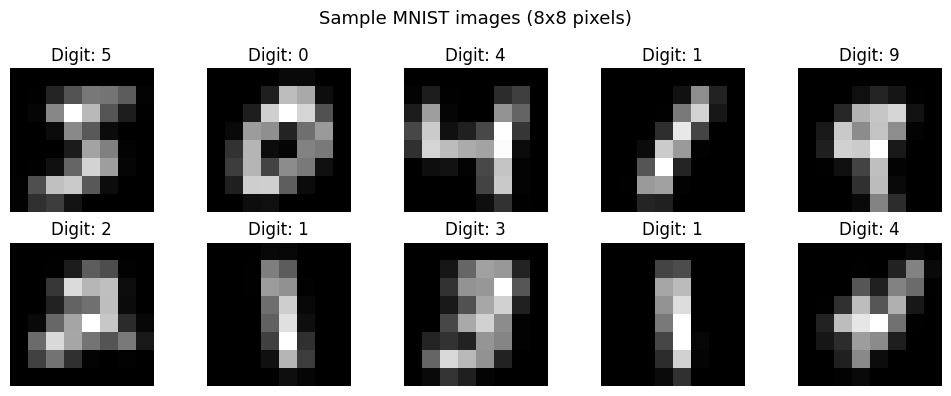

Each image shape: torch.Size([1, 8, 8])
Pixel values range: 0.0 to 1.0
Total images: 60000


In [1]:
# Cell 1: Imports & Data Loading
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import datasets, transforms

# Download MNIST and resize images to 8x8
transform = transforms.Compose([
    transforms.Resize((8, 8)),
    transforms.ToTensor()
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Let's just look at what we're working with
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Digit: {label}')
    ax.axis('off')
plt.suptitle('Sample MNIST images (8x8 pixels)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Each image shape: {dataset[0][0].shape}")
print(f"Pixel values range: 0.0 to 1.0")
print(f"Total images: {len(dataset)}")

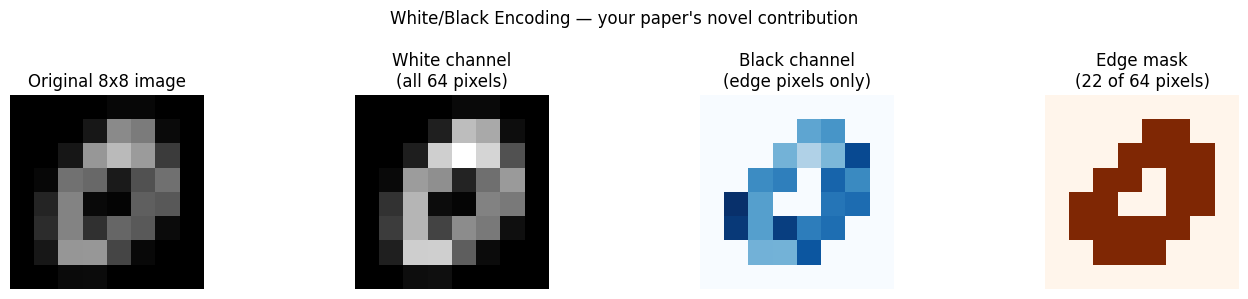

Amplitude vector length: 2048 (2^11 = 2048)
Edge pixels dual-encoded: 22
Why it matters: preserves contrast that standard normalization destroys


In [2]:
# Cell 2: White/Black Amplitude Encoding
# This is the novel contribution from your paper

def white_black_encode(image_tensor):
    """
    Encode an 8x8 image into a 2048-length amplitude vector.
    
    Problem with standard encoding: L2 normalization destroys brightness contrast.
    Two images with same pattern but different brightness become identical quantum states.
    
    Our fix: encode edge pixels TWICE — once as brightness, once as darkness.
    This preserves the log-odds ratio of each pixel, saving contrast information.
    """
    pixels = image_tensor.squeeze().numpy().flatten() * 16  # scale to [0, 16]
    
    alpha = np.zeros(2048)
    
    for i, p in enumerate(pixels):
        # WHITE CHANNEL (indices 0-63): every pixel, by brightness
        alpha[i] = p / 16.0
        
        # BLACK CHANNEL (indices 64-127): only edge pixels (not pure black or white)
        if 2 <= p <= 14:
            alpha[i + 64] = 1 - (p / 16.0)  # complementary intensity
    
    # Normalize so amplitudes are a valid quantum state
    norm = np.linalg.norm(alpha)
    if norm > 0:
        alpha = alpha / norm
    
    return alpha

# --- Visualize on a digit 0 ---
for img, label in dataset:
    if label == 0:
        sample = img
        break

pixels_raw = sample.squeeze().numpy() * 16
alpha = white_black_encode(sample)
edge_mask = (pixels_raw >= 2) & (pixels_raw <= 14)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))

axes[0].imshow(pixels_raw, cmap='gray', vmin=0, vmax=16)
axes[0].set_title('Original 8x8 image')

axes[1].imshow(alpha[:64].reshape(8, 8), cmap='gray')
axes[1].set_title('White channel\n(all 64 pixels)')

black_vis = np.zeros((8, 8))
black_vis[edge_mask] = alpha[64:128].reshape(8, 8)[edge_mask]
axes[2].imshow(black_vis, cmap='Blues')
axes[2].set_title('Black channel\n(edge pixels only)')

axes[3].imshow(edge_mask, cmap='Oranges')
axes[3].set_title(f'Edge mask\n({edge_mask.sum()} of 64 pixels)')

for ax in axes:
    ax.axis('off')

plt.suptitle("White/Black Encoding — your paper's novel contribution", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Amplitude vector length: {len(alpha)} (2^11 = 2048)")
print(f"Edge pixels dual-encoded: {edge_mask.sum()}")
print(f"Why it matters: preserves contrast that standard normalization destroys")

In [3]:
# Cell 3: Build the 11-Qubit Quantum Circuit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import RealAmplitudes

# --- Step 1: The input encoding circuit ---
# We have 2048 amplitude values but only need 11 rotation angles
# So we use a linear projection: 2048 -> 11 angles
# (6 angles for white channel qubits 0-5, 5 for black channel qubits 6-10)

def encode_to_angles(alpha):
    """Project 2048-length amplitude vector down to 11 rotation angles."""
    white = alpha[:64]   # white channel pixels
    black = alpha[64:128]  # black channel pixels
    
    # Simple linear projection: split each channel into groups, take mean
    white_angles = np.array([white[i*10:(i+1)*10].mean() for i in range(6)]) * np.pi
    black_angles = np.array([black[i*12:(i+1)*12].mean() for i in range(5)]) * np.pi
    
    return np.concatenate([white_angles, black_angles])  # 11 angles total

# --- Step 2: Build the parameterized quantum circuit ---
n_qubits = 11

# RealAmplitudes ansatz: applies RY rotations + entangling CNOT gates
# reps=1 means one layer of this pattern (depth 22, gives us 22 trainable weights)
ansatz = RealAmplitudes(n_qubits, reps=1, entanglement='full')

print(f"Ansatz parameters: {ansatz.num_parameters}")
print(f"Circuit depth: {ansatz.decompose().depth()}")

# --- Step 3: Visualize the circuit ---
# Show just a 4-qubit version so it fits on screen (same structure, just smaller)
small_demo = RealAmplitudes(4, reps=1, entanglement='full')
print("\n4-qubit demo circuit (same structure as our 11-qubit circuit):")
print(small_demo.decompose())

# --- Step 4: Show what one encoded sample looks like ---
sample_alpha = white_black_encode(sample)  # reuse digit 0 from Cell 2
sample_angles = encode_to_angles(sample_alpha)

print(f"\nEncoding pipeline for one image:")
print(f"  8x8 pixels (64 values)")
print(f"  → amplitude vector (2048 values)")  
print(f"  → 11 rotation angles: {np.round(sample_angles, 3)}")
print(f"\nThese 11 angles become the RY gate rotations on qubits 0-10")
print(f"Then the ansatz's 22 trainable weights adjust during training")
print(f"Total trainable parameters: 22 (quantum) + 2 (classical output) = 24")

Ansatz parameters: 22
Circuit depth: 21

4-qubit demo circuit (same structure as our 11-qubit circuit):
     ┌──────────┐                    ┌──────────┐                        
q_0: ┤ Ry(θ[0]) ├──■────■─────────■──┤ Ry(θ[4]) ├────────────────────────
     ├──────────┤┌─┴─┐  │         │  └──────────┘┌──────────┐            
q_1: ┤ Ry(θ[1]) ├┤ X ├──┼────■────┼───────■──────┤ Ry(θ[5]) ├────────────
     ├──────────┤└───┘┌─┴─┐┌─┴─┐  │       │      └──────────┘┌──────────┐
q_2: ┤ Ry(θ[2]) ├─────┤ X ├┤ X ├──┼───────┼───────────■──────┤ Ry(θ[6]) ├
     ├──────────┤     └───┘└───┘┌─┴─┐   ┌─┴─┐       ┌─┴─┐    ├──────────┤
q_3: ┤ Ry(θ[3]) ├───────────────┤ X ├───┤ X ├───────┤ X ├────┤ Ry(θ[7]) ├
     └──────────┘               └───┘   └───┘       └───┘    └──────────┘

Encoding pipeline for one image:
  8x8 pixels (64 values)
  → amplitude vector (2048 values)
  → 11 rotation angles: [0.005 0.164 0.256 0.167 0.158 0.14  0.    0.21  0.277 0.346 0.115]

These 11 angles become the RY gate rotation

C:\Users\13213\AppData\Local\Temp\ipykernel_2492\774107069.py:27: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(n_qubits, reps=1, entanglement='full')
C:\Users\13213\AppData\Local\Temp\ipykernel_2492\774107069.py:34: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  small_demo = RealAmplitudes(4, reps=1, entanglement='full')


In [4]:
# Cell 4: Binary Classifier Training (Digit 0 vs Digit 1)
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.circuit.library import RealAmplitudes
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.quantum_info import SparsePauliOp
import torch
import torch.nn as nn
import torch.optim as optim
import time

# --- Build the full QNN circuit ---
n_qubits = 11
input_params = ParameterVector('x', n_qubits)

# Input encoding: RY gate on each qubit
qc = QuantumCircuit(n_qubits)
for i in range(n_qubits):
    qc.ry(input_params[i], i)

# Trainable ansatz
ansatz = RealAmplitudes(n_qubits, reps=1, entanglement='full',
                        parameter_prefix='w')
qc.compose(ansatz, inplace=True)

# Observable: measure qubit 0 in Z basis (gives +1 or -1)
observable = SparsePauliOp('Z' + 'I' * (n_qubits - 1))

# Wrap in EstimatorQNN
estimator = Estimator()
qnn = EstimatorQNN(
    circuit=qc,
    observables=observable,
    input_params=input_params.params,
    weight_params=ansatz.parameters,
    estimator=estimator
)

# Wrap with TorchConnector so PyTorch can train it
model = nn.Sequential(
    TorchConnector(qnn),
    nn.Linear(1, 1)
)

# --- Prepare dataset: only digits 0 and 1, 50 each = 100 total ---
X_data, y_data = [], []
count = {0: 0, 1: 0}

for img, label in dataset:
    if label in [0, 1] and count[label] < 50:
        alpha = white_black_encode(img)
        angles = encode_to_angles(alpha)
        X_data.append(angles)
        y_data.append(-1.0 if label == 0 else 1.0)  # 0 → -1, 1 → +1
        count[label] += 1
    if count[0] == 50 and count[1] == 50:
        break

X_tensor = torch.tensor(np.array(X_data), dtype=torch.float32)
y_tensor = torch.tensor(y_data, dtype=torch.float32).unsqueeze(1)

# 80 train, 20 test
X_train, X_test = X_tensor[:80], X_tensor[80:]
y_train, y_test = y_tensor[:80], y_tensor[80:]

# --- Training loop ---
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

train_losses, train_accs, test_accs = [], [], []

print("Starting training... (15-30 mins)")
print(f"{'Epoch':>5} | {'Loss':>8} | {'Train Acc':>10} | {'Test Acc':>9} | {'Time':>6}")
print("-" * 50)

for epoch in range(15):
    start = time.time()
    model.train()

    total_loss = 0
    for i in range(len(X_train)):
        optimizer.zero_grad()
        pred = model(X_train[i].unsqueeze(0))
        loss = loss_fn(pred, y_train[i].unsqueeze(0))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    with torch.no_grad():
        train_pred = model(X_train)
        test_pred  = model(X_test)
        train_acc = ((train_pred.sign() == y_train).float().mean() * 100).item()
        test_acc  = ((test_pred.sign() == y_test).float().mean() * 100).item()

    avg_loss = total_loss / len(X_train)
    elapsed = time.time() - start
    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"{epoch+1:>5} | {avg_loss:>8.4f} | {train_acc:>9.1f}% | {test_acc:>8.1f}% | {elapsed:>5.1f}s")

print("\nTraining complete!")
print(f"Final test accuracy: {test_accs[-1]:.1f}%")

C:\Users\13213\AppData\Local\Temp\ipykernel_2492\543654963.py:23: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(n_qubits, reps=1, entanglement='full',
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Starting training... (15-30 mins)
Epoch |     Loss |  Train Acc |  Test Acc |   Time
--------------------------------------------------
    1 |   1.0631 |      65.0% |     25.0% |  32.2s
    2 |   0.9978 |      53.8% |     35.0% |  36.6s
    3 |   0.9978 |      53.8% |     35.0% |  35.7s
    4 |   0.9969 |      53.8% |     35.0% |  28.4s
    5 |   0.9955 |      53.8% |     35.0% |  29.2s
    6 |   0.9939 |      53.8% |     35.0% |  29.4s
    7 |   0.9936 |      53.8% |     35.0% |  29.2s
    8 |   0.9918 |      53.8% |     35.0% |  29.1s
    9 |   0.9900 |      53.8% |     35.0% |  29.3s
   10 |   0.9886 |      53.8% |     35.0% |  29.0s
   11 |   0.9901 |      53.8% |     35.0% |  17.0s
   12 |   0.9877 |      53.8% |     35.0% |  36.7s
   13 |   0.9852 |      53.8% |     35.0% |  37.4s
   14 |   0.9847 |      53.8% |     35.0% |  35.5s
   15 |   0.9805 |      55.0% |     35.0% |  37.4s

Training complete!
Final test accuracy: 35.0%


In [5]:
# Cell 4b: Continue training for 15 more epochs
print("Continuing training...")
print(f"{'Epoch':>5} | {'Loss':>8} | {'Train Acc':>10} | {'Test Acc':>9} | {'Time':>6}")
print("-" * 50)

for epoch in range(15):
    start = time.time()
    model.train()

    total_loss = 0
    for i in range(len(X_train)):
        optimizer.zero_grad()
        pred = model(X_train[i].unsqueeze(0))
        loss = loss_fn(pred, y_train[i].unsqueeze(0))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    with torch.no_grad():
        train_pred = model(X_train)
        test_pred  = model(X_test)
        train_acc = ((train_pred.sign() == y_train).float().mean() * 100).item()
        test_acc  = ((test_pred.sign() == y_test).float().mean() * 100).item()

    avg_loss = total_loss / len(X_train)
    elapsed = time.time() - start
    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"{epoch+16:>5} | {avg_loss:>8.4f} | {train_acc:>9.1f}% | {test_acc:>8.1f}% | {elapsed:>5.1f}s")

print(f"\nBest test accuracy so far: {max(test_accs):.1f}%")

Continuing training...
Epoch |     Loss |  Train Acc |  Test Acc |   Time
--------------------------------------------------
   16 |   0.9752 |      53.8% |     35.0% |  38.4s
   17 |   0.9762 |      57.5% |     35.0% |  37.7s
   18 |   0.9701 |      60.0% |     45.0% |  35.9s
   19 |   0.9739 |      61.2% |     35.0% |  28.2s
   20 |   0.9607 |      60.0% |     50.0% |  35.7s
   21 |   0.9594 |      68.8% |     55.0% |  36.9s
   22 |   0.9571 |      70.0% |     50.0% |  36.2s
   23 |   0.9570 |      70.0% |     55.0% |  35.0s
   24 |   0.9492 |      73.8% |     65.0% |  38.0s
   25 |   0.9412 |      75.0% |     65.0% |  36.7s
   26 |   0.9395 |      76.2% |     65.0% |  37.8s
   27 |   0.9313 |      77.5% |     65.0% |  37.4s
   28 |   0.9280 |      75.0% |     70.0% |  37.3s
   29 |   0.9202 |      78.8% |     80.0% |  38.5s
   30 |   0.9130 |      77.5% |     70.0% |  19.9s

Best test accuracy so far: 80.0%


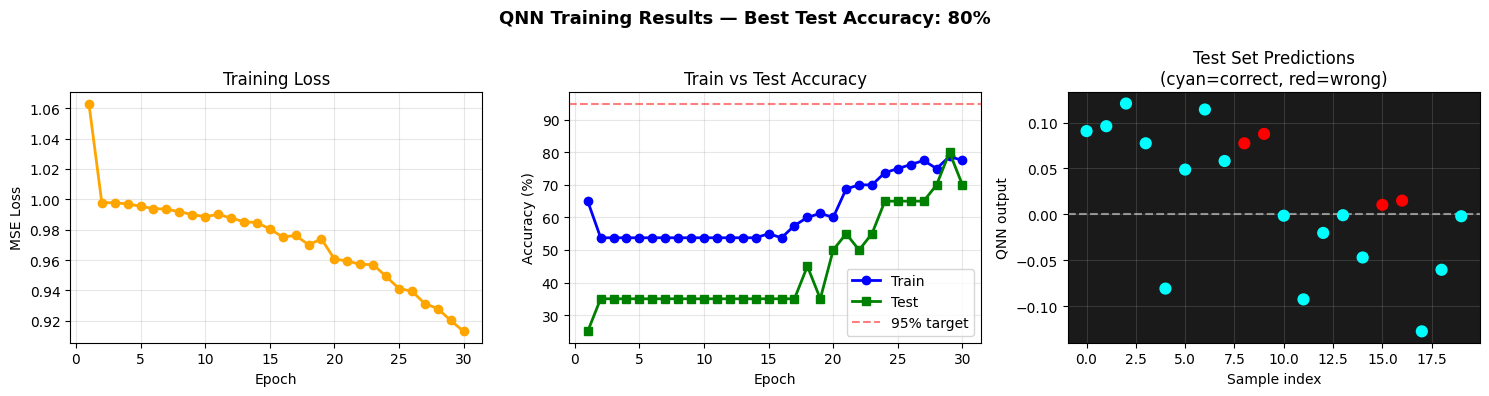

Total epochs trained: 30
Best test accuracy: 80.0%
Final loss: 0.9130
Trainable parameters: 24 (22 quantum + 2 classical)


In [6]:
# Cell 5: Plot Training Results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs = range(1, len(train_losses) + 1)

# Plot 1: Loss curve
axes[0].plot(epochs, train_losses, 'o-', color='orange', linewidth=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy curves
axes[1].plot(epochs, train_accs, 'o-', label='Train', color='blue', linewidth=2)
axes[1].plot(epochs, test_accs, 's-', label='Test', color='green', linewidth=2)
axes[1].axhline(y=95, color='red', linestyle='--', alpha=0.5, label='95% target')
axes[1].set_title('Train vs Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Scatter of final predictions on test set
model.eval()
with torch.no_grad():
    test_preds = model(X_test).squeeze().numpy()

correct = (np.sign(test_preds) == y_test.squeeze().numpy())
axes[2].scatter(range(len(test_preds)), test_preds,
                c=['cyan' if c else 'red' for c in correct], s=60, zorder=3)
axes[2].axhline(y=0, color='white', linestyle='--', alpha=0.5)
axes[2].set_facecolor('#1a1a1a')
axes[2].set_title('Test Set Predictions\n(cyan=correct, red=wrong)')
axes[2].set_xlabel('Sample index')
axes[2].set_ylabel('QNN output')
axes[2].grid(True, alpha=0.2)

plt.suptitle(f'QNN Training Results — Best Test Accuracy: {max(test_accs):.0f}%', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total epochs trained: {len(train_losses)}")
print(f"Best test accuracy: {max(test_accs):.1f}%")
print(f"Final loss: {train_losses[-1]:.4f}")
print(f"Trainable parameters: 24 (22 quantum + 2 classical)")

In [ ]:
# Cell 6: Multiclass Extension (All 10 Digits)
# Instead of 1 Pauli-Z measurement, we use 10 — one per digit class
from qiskit.quantum_info import SparsePauliOp

# --- Build new circuit with 10 observables ---
n_qubits = 11

input_params_mc = ParameterVector('x', n_qubits)

qc_mc = QuantumCircuit(n_qubits)
for i in range(n_qubits):
    qc_mc.ry(input_params_mc[i], i)

ansatz_mc = RealAmplitudes(n_qubits, reps=1, entanglement='full',
                           parameter_prefix='w')
qc_mc.compose(ansatz_mc, inplace=True)

# 10 observables: measure each of qubits 0-9 in Z basis, one per digit
observables_mc = [
    SparsePauliOp('I' * (n_qubits - 1 - i) + 'Z' + 'I' * i)
    for i in range(10)
]

estimator_mc = Estimator()
qnn_mc = EstimatorQNN(
    circuit=qc_mc,
    observables=observables_mc,
    input_params=input_params_mc.params,
    weight_params=ansatz_mc.parameters,
    estimator=estimator_mc
)

# No classical output layer — purely quantum classifier (22 parameters only)
model_mc = TorchConnector(qnn_mc)

# --- Prepare dataset: 10 of each digit = 100 samples total ---
X_mc, y_mc = [], []
count_mc = {i: 0 for i in range(10)}

for img, label in dataset:
    label = int(label)
    if count_mc[label] < 10:
        alpha = white_black_encode(img)
        angles = encode_to_angles(alpha)
        X_mc.append(angles)
        y_mc.append(label)
        count_mc[label] += 1
    if all(v == 10 for v in count_mc.values()):
        break

X_mc_tensor = torch.tensor(np.array(X_mc), dtype=torch.float32)
y_mc_tensor = torch.tensor(y_mc, dtype=torch.long)

# 80 train, 20 test
X_mc_train, X_mc_test = X_mc_tensor[:80], X_mc_tensor[80:]
y_mc_train, y_mc_test = y_mc_tensor[:80], y_mc_tensor[80:]

# --- Training ---
optimizer_mc = optim.Adam(model_mc.parameters(), lr=0.01)
loss_fn_mc = nn.CrossEntropyLoss()

print("Training multiclass QNN (10 digits)... (~15 mins)")
print(f"{'Epoch':>5} | {'Loss':>8} | {'Train Acc':>10} | {'Test Acc':>9} | {'Time':>6}")
print("-" * 50)

mc_train_losses, mc_train_accs, mc_test_accs = [], [], []

for epoch in range(15):
    start = time.time()
    model_mc.train()

    total_loss = 0
    for i in range(len(X_mc_train)):
        optimizer_mc.zero_grad()
        pred = model_mc(X_mc_train[i].unsqueeze(0))
        loss = loss_fn_mc(pred, y_mc_train[i].unsqueeze(0))
        loss.backward()
        optimizer_mc.step()
        total_loss += loss.item()

    model_mc.eval()
    with torch.no_grad():
        train_pred = model_mc(X_mc_train).argmax(dim=1)
        test_pred  = model_mc(X_mc_test).argmax(dim=1)
        train_acc = (train_pred == y_mc_train).float().mean().item() * 100
        test_acc  = (test_pred == y_mc_test).float().mean().item() * 100

    avg_loss = total_loss / len(X_mc_train)
    elapsed = time.time() - start
    mc_train_losses.append(avg_loss)
    mc_train_accs.append(train_acc)
    mc_test_accs.append(test_acc)

    print(f"{epoch+1:>5} | {avg_loss:>8.4f} | {train_acc:>9.1f}% | {test_acc:>8.1f}% | {elapsed:>5.1f}s")

print(f"\nMulticlass training complete!")
print(f"Best test accuracy: {max(mc_test_accs):.1f}% across 10 digit classes")
~print(f"Trainable parameters: {sum(p.numel() for p in model_mc.parameters())} (purely quantum)")

C:\Users\13213\AppData\Local\Temp\ipykernel_2492\2965965578.py:14: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz_mc = RealAmplitudes(n_qubits, reps=1, entanglement='full',
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Training multiclass QNN (10 digits)... (~15 mins)
Epoch |     Loss |  Train Acc |  Test Acc |   Time
--------------------------------------------------
    1 |   2.3107 |      12.5% |      0.0% | 328.1s
    2 |   2.2998 |      12.5% |      0.0% | 304.0s
    3 |   2.2907 |      11.2% |      0.0% | 280.0s
    4 |   2.2865 |      16.2% |      0.0% | 304.8s
    5 |   2.2858 |      15.0% |      0.0% | 226.3s
    6 |   2.2851 |      15.0% |      0.0% | 185.7s
    7 |   2.2815 |      16.2% |      0.0% | 270.9s
    8 |   2.2786 |      17.5% |      0.0% | 294.4s


KeyboardInterrupt: 